# **Notebook 2c: Test evaluation of model 2**

Evaluates the RobBERT classifier trained on manually labeled data only + makes extra plots and prints other details of both model 2 and 3b for deeper insight.

## 1. Importing packages

In [ ]:
import os
import json
import torch
import numpy as np
import pandas as pd
import torch.nn.functional as F
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

## 2. Preparation

In [ ]:
MODEL_DIR      = "./model_1"
TEST_DATA_PATH = "labeled_test.csv"
THRESHOLD_PATH = "./model_1/threshold.json"
MODEL_NAME     = "pdelobelle/robbert-v2-dutch-base"
MAX_LENGTH     = 100
LABEL_COL      = "unnecessary"
SENT_COL       = "blurb_sent"
BATCH_SIZE     = 16

## 3. Load data and model

In [ ]:
# Loading test dataset
test_df = pd.read_csv(TEST_DATA_PATH)
drop_cols = [c for c in ["sent_position", "final_edit", "blurb"] if c in test_df.columns]
test_df = test_df.drop(columns=drop_cols)
print(f"Test: {len(test_df)} sentences, {test_df[LABEL_COL].mean():.1%} positive")

Test: 481 sentences, 23.1% positive


In [ ]:
# Loading model and tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR, use_fast=True)
model     = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)
print("Model and tokenizer loaded")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model and tokenizer loaded


## 4. Generating test probabilities

In [ ]:
def tokenize(batch):
    return tokenizer(batch[SENT_COL], truncation=True, max_length=MAX_LENGTH)

def df_to_dataset(d):
    ds = Dataset.from_pandas(
        d[[SENT_COL, LABEL_COL]].rename(columns={LABEL_COL: "labels"}),
        preserve_index=False)
    return ds.map(tokenize, batched=True)

test_ds = df_to_dataset(test_df)

# Using Trainer for prediction
args = TrainingArguments(output_dir="./tmp_eval", per_device_eval_batch_size=BATCH_SIZE, report_to="none")
trainer = Trainer(model=model, args=args, data_collator=DataCollatorWithPadding(tokenizer))

test_predictions = trainer.predict(test_ds)
test_logits = test_predictions.predictions
test_labels = test_predictions.label_ids
test_probs  = F.softmax(torch.tensor(test_logits), dim=-1).numpy()[:, 1]
print(f"Generated predictions for {len(test_probs)} sentences")

Map:   0%|          | 0/481 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Generated predictions for 481 sentences


In [ ]:
# Loading threshold and generate predictions
with open(THRESHOLD_PATH) as f:
    CHOSEN_THRESHOLD = json.load(f)["threshold"]
print(f"Threshold: {CHOSEN_THRESHOLD}")

test_sentences = test_df[SENT_COL].tolist()
test_preds = (test_probs >= CHOSEN_THRESHOLD).astype(int)

Threshold: 0.6200000000000001


In [ ]:
# Save predictions
np.save("./model_1/test_probs.npy", test_probs)
np.save("./model_1/test_labels.npy", test_labels)

## 5. Evaluation

In [ ]:
# Metrics
print(classification_report(test_labels, test_preds,
    target_names=["necessary (0)", "unnecessary (1)"], digits=3))
print(f"Macro F1 : {f1_score(test_labels, test_preds, average='macro'):.3f}")
print(f"AUC      : {roc_auc_score(test_labels, test_probs):.3f}")

                 precision    recall  f1-score   support

  necessary (0)      0.886     0.943     0.914       370
unnecessary (1)      0.759     0.595     0.667       111

       accuracy                          0.863       481
      macro avg      0.822     0.769     0.790       481
   weighted avg      0.856     0.863     0.857       481

Macro F1 : 0.790
AUC      : 0.884


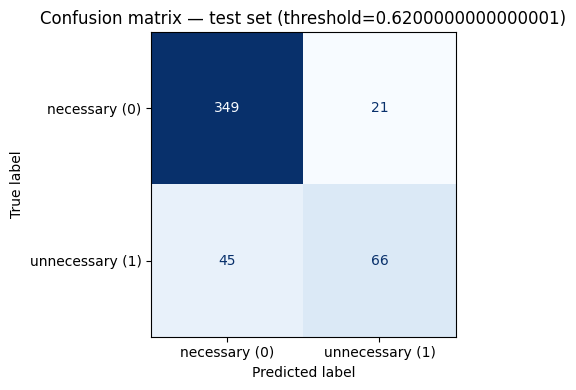

In [ ]:
# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm,
    display_labels=["necessary (0)", "unnecessary (1)"]).plot(
    ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion matrix — test set (threshold={CHOSEN_THRESHOLD})")
plt.tight_layout()
plt.show()

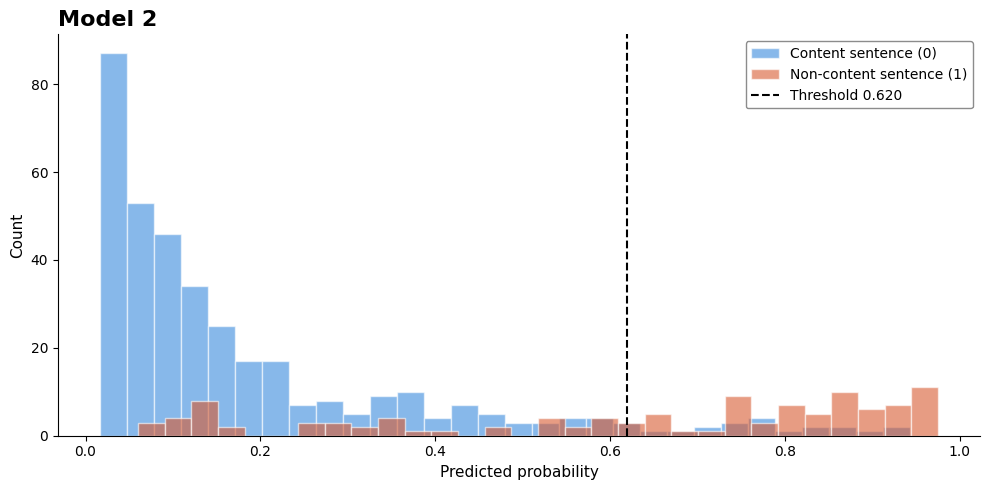

In [ ]:
# Probability distribution
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(test_probs[test_labels == 0], bins=30, alpha=0.6, label="Content sentence (0)",
        color="#378ADD", edgecolor="white")
ax.hist(test_probs[test_labels == 1], bins=30, alpha=0.6, label="Non-content sentence (1)",
        color="#D85A30", edgecolor="white")
ax.axvline(CHOSEN_THRESHOLD, linestyle="--", color="black", linewidth=1.5, label=f"Threshold {CHOSEN_THRESHOLD:.3f}")

ax.set_xlabel("Predicted probability", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("Model 2", fontsize=16, fontweight="bold", loc="left")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(True)
ax.spines["bottom"].set_color("black")

ax.legend(frameon=True, fontsize=10, loc="upper right", facecolor="white", edgecolor="gray", framealpha=0.9)

plt.tight_layout()
plt.show()